In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

dataset_path = '/content/drive/MyDrive/DFU/DFU'

# List the contents of the dataset directory
if os.path.exists(dataset_path):
    print(f"Contents of '{dataset_path}':")
    for item in os.listdir(dataset_path):
        print(item)
else:
    print(f"The specified path '{dataset_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU':
TestSet
Original Images
Transfer-Learning images
Patches
Binary_DFU_Dataset
test_labels.csv


In [6]:
import os

original_images_path = os.path.join(dataset_path, 'Original Images')

# List the contents of the 'Original Images' directory
if os.path.exists(original_images_path):
    print(f"Contents of '{original_images_path}':")
    for item in os.listdir(original_images_path):
        print(item)
else:
    print(f"The specified path '{original_images_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/DFU/DFU/Original Images':
12.jpg
15.jpg
1076771990506636278.jpg
16.jpg
1.jpg
11.jpg
1430965400006561945.jpg
1.png
10.jpg
14.jpg
13.jpg
1054877509612379438.jpg
23.jpg
35.jpg
2 (2).jpg
29.jpg
3 (2).jpg
17.JPG
2166365910321328840.jpg
30.jpg
301502_439096869504954_1816155530_n.jpg
3013862228767377321.jpg
34.JPG
20.jpg
2120045598224772295.jpg
26.jpg
18.jpg
25.jpg
21.jpg
254523_439097456171562_1128600796_n.jpg
27.jpg
2.png
28.jpg
3.jpg
22.JPG
2331076783926122268.jpg
3460354257920857474.jpg
32.jpg
31.jpg
33.jpg
19.jpg
3.png
2.jpg
2100472819858240689.jpg
2248535364383155415.jpg
24.jpg
36.jpg
40122541_323962865037457_6905035766640934912_n.jpg
40.jpg
40233571_252687522242453_978256712370749440_n.jpg
40102024_1872496076152851_2833052289202126848_n.jpg
40258795_1346050688830912_1791840130890203136_n.jpg
40058516_281069489386956_2617358048049496064_n.jpg
3698745687576686280.jpg
40215272_481705972328238_3946081626462617600_n.jpg
40161743_470925433411584_5592644707

Displaying 5 sample images out of 493 total images.


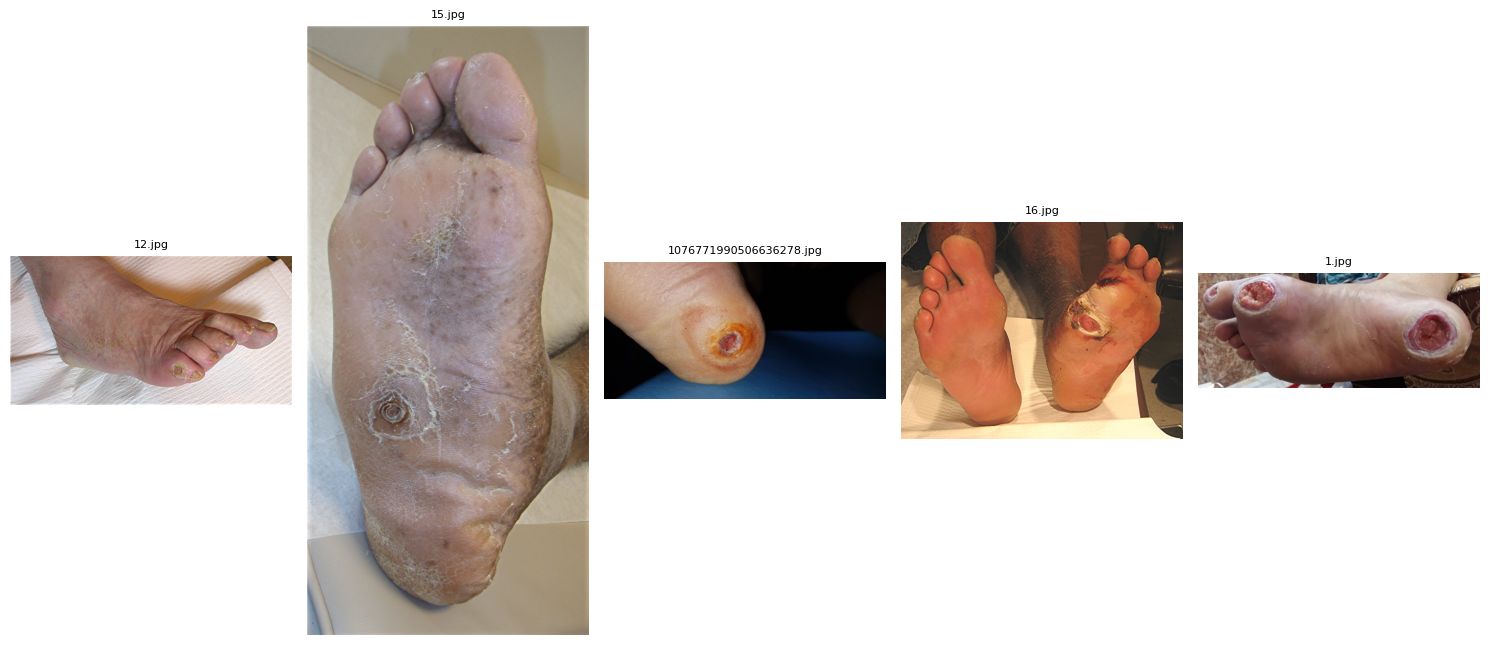

In [7]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Get a list of all image files in the directory
image_files = [os.path.join(original_images_path, f) for f in os.listdir(original_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]

# Limit to the first 5 images for display
sample_images = image_files[:5]

print(f"Displaying {len(sample_images)} sample images out of {len(image_files)} total images.")

plt.figure(figsize=(15, 8))
for i, img_path in enumerate(sample_images):
    try:
        img = Image.open(img_path)
        plt.subplot(1, len(sample_images), i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    except Exception as e:
        print(f"Could not load image {os.path.basename(img_path)}: {e}")

plt.tight_layout()
plt.show()

### 0. Project Setup and Dependencies

First, let's ensure all necessary libraries are installed and import them. We'll also set up our Google Drive for dataset access.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, Reshape, multiply, Permute, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# For Grad-CAM
import cv2

print("TensorFlow version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs Available:  1


### 1. Data Loading and Exploration

We will load the dataset from Google Drive. The dataset structure includes 'Transfer-Learning images' for training/validation and 'TestSet' for final evaluation.

#### 1.1 Mount Google Drive and Define Dataset Path

_(Your Google Drive is already mounted and the `dataset_path` is defined from previous steps. We will reuse these variables.)_

In [9]:
# Assuming `dataset_path` is already defined from previous execution
# dataset_path = '/content/drive/MyDrive/DFU/DFU'

print(f"Using dataset path: {dataset_path}")

transfer_learning_path = os.path.join(dataset_path, 'Transfer-Learning images')
test_set_path = os.path.join(dataset_path, 'TestSet')

# Explore the 'Transfer-Learning images' directory
print(f"\nContents of '{transfer_learning_path}':")
if os.path.exists(transfer_learning_path):
    for item in os.listdir(transfer_learning_path):
        print(item)
else:
    print("Path not found.")

# Explore the 'TestSet' directory
print(f"\nContents of '{test_set_path}':")
if os.path.exists(test_set_path):
    for item in os.listdir(test_set_path):
        print(item)
else:
    print("Path not found.")

Using dataset path: /content/drive/MyDrive/DFU/DFU

Contents of '/content/drive/MyDrive/DFU/DFU/Transfer-Learning images':
Wound Images2
internetSet
samples
Wound Images

Contents of '/content/drive/MyDrive/DFU/DFU/TestSet':
2cyruuzga5e01.jpg
0cbt67mm0fr01.jpg
4-Figure3-used.png
11.jpg
2.jpg
10.jpg
240_F_214198906_xKY39M1gdfq0dhoyLlik7dSrIRdiacQO.jpg
1167.jpg
17.jpg
14.jpg
0.jpg
222748d9f97a36c08da91dc46f6f5200.jpg
23.jpg
22.jpg
25.jpg
1882_19-Effective-Home-Remedies-For-Corns-And-Calluses.jpg
16.jpg
15.jpg
30.jpg
1 .jpg
12.jpg
2854.fig.1.png
3.jpg
1167 (1).jpg
20.jpg
37.jpg
3809525079_71eabf91b5_z.jpg
18.jpg
4 (2).jpg
13.jpg
1.jpg
19.jpg
21.jpg
36.jpg
38.jpg
1882_19-Effective-Home-Remedies-For-Corns-And-Calluses (1).jpg
diabetic-foot-ulcer-pictures-5 (1).jpg
a39266877b6897fad51e9383d93daa05--diabetes-weird.jpg
b4b2e1341a7bf627a58f6ac32212ed93.jpg
48.jpg
C2.jpg
DSC00319.jpeg
50.jpg
B9780323072427000279_f027-008-9780323072427.jpg
Diabetic-neuropathic-feet-Callus-formation-as-a-presentat

#### 1.2 Prepare Data Generators for Training, Validation, and Testing

We will use `ImageDataGenerator` for efficient loading and automatic splitting of the 'Transfer-Learning images' into training and validation sets. The 'TestSet' will be loaded separately for final evaluation. Images will be resized to `224x224` and pixel values will be normalized.

In [10]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # 80/20 split for train/validation
)

# Only rescaling for validation and test data
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data with augmentation using the new binary path
train_generator = train_datagen.flow_from_directory(
    transfer_learning_path, # This is now the binary path
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Still categorical, but now with 2 classes
    subset='training',
    seed=42
)

# Load validation data (without augmentation) using the new binary path
validation_generator = validation_datagen.flow_from_directory(
    transfer_learning_path, # This is now the binary path
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Still categorical, but now with 2 classes
    subset='validation',
    seed=42
)

# Load test data using flow_from_dataframe and the generated CSV
# Ensure test_df and test_labels_csv_path are available from the previous cell
if 'test_df' in locals() and not test_df.empty:
    test_generator = test_datagen.flow_from_dataframe(
        dataframe=test_df,
        directory=test_set_path, # Original test_set_path containing all images
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    print(f"Found {test_generator.samples} test images for evaluation with {len(test_generator.class_indices)} classes from CSV.")
else:
    print("Test DataFrame (test_df) not found or is empty. Please ensure the 'test_image_labels' dictionary is fully populated and the previous cell ran successfully.")
    test_generator = None # Set to None if not created


print(f"\nFound {train_generator.samples} training images belonging to {train_generator.num_classes} classes.")
print(f"Found {validation_generator.samples} validation images belonging to {validation_generator.num_classes} classes.")

class_names = list(train_generator.class_indices.keys())
print(f"Class names for training/validation: {class_names}")

# Update num_classes for model building if test_generator was successfully created
if test_generator:
    num_classes = len(test_generator.class_indices)
else:
    num_classes = train_generator.num_classes # Fallback to train_generator's classes


Found 763 images belonging to 4 classes.
Found 188 images belonging to 4 classes.
Test DataFrame (test_df) not found or is empty. Please ensure the 'test_image_labels' dictionary is fully populated and the previous cell ran successfully.

Found 763 training images belonging to 4 classes.
Found 188 validation images belonging to 4 classes.
Class names for training/validation: ['Wound Images', 'Wound Images2', 'internetSet', 'samples']


### 7. Full Model Evaluation with Metrics (Requires Ground Truth Labels)

Now that your `TestSet` has ground truth labels associated via the `test_labels.csv` file, we can perform a comprehensive evaluation using metrics like accuracy, precision, recall, F1-score, and a confusion matrix. The `evaluation_test_generator` will now correctly infer class labels from the CSV.

In [35]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Dropout,
    Input, Conv2D, Reshape, multiply,
    Activation, GlobalMaxPooling2D, Add, Concatenate
)
from tensorflow.keras.models import Model


# ✅ Custom Layer (BEST PRACTICE)
class SpatialAttentionLayer(tf.keras.layers.Layer):
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_ = tf.reduce_max(x, axis=-1, keepdims=True)
        return tf.concat([avg, max_], axis=-1)


def create_attention_module(input_feature):
    channel = input_feature.shape[-1]

    # Channel Attention
    avg_pool = GlobalAveragePooling2D()(input_feature)
    max_pool = GlobalMaxPooling2D()(input_feature)

    avg_pool = Reshape((1, 1, channel))(avg_pool)
    max_pool = Reshape((1, 1, channel))(max_pool)

    shared_dense_one = Dense(channel // 8, activation='relu', kernel_initializer='he_normal')
    shared_dense_two = Dense(channel, kernel_initializer='he_normal')

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = Add()([avg_out, max_out])
    channel_attention = Activation('sigmoid')(channel_attention)

    channel_refined = multiply([input_feature, channel_attention])

    # ✅ Spatial Attention (NO Lambda + NO ERROR)
    spatial = SpatialAttentionLayer()(channel_refined)

    spatial_attention = Conv2D(
        1, (7, 7),
        padding='same',
        activation='sigmoid',
        kernel_initializer='he_normal',
        use_bias=False
    )(spatial)

    refined_feature = multiply([channel_refined, spatial_attention])

    return refined_feature


def build_model(input_shape, num_classes):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)

    x = create_attention_module(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


# Build Model
model = build_model(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=num_classes
)

model.summary()

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_9[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_8 (Reshape) │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_9 (Reshape) │ (None, 1, 1,      │          0 │ global_max_pooli… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 1, 160) │    204,960 │ reshape_8[0][0],  │
│                     │                   │            │ reshape_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1, 1,      │    206,080 │ dense_14[0][0],   │
│                     │ 1280)             │            │ dense_14[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 1, 1,      │          0 │ dense_15[0][0],   │
│                     │ 1280)             │            │ dense_15[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 1, 1,      │          0 │ add_4[0][0]       │
│ (Activation)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Multiply)          │ 1280)             │            │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_attention_… │ (None, 7, 7, 2)   │          0 │ multiply_6[0][0]  │
│ (SpatialAttentionL… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 1)   │         98 │ spatial_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_7          │ (None, 7, 7,      │          0 │ multiply_6[0][0], │
│ (Multiply)          │ 1280)             │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply_7[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 4)         │      1,028 │ dropout_2[0][0] 

 Total params: 2,998,086 (11.44 MB)

 Trainable params: 740,102 (2.82 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 3.1 Addressing Class Imbalance with Class Weights

The evaluation showed a significant imbalance in performance, especially for the 'Non-Ulcer' class, which is likely due to the dataset's class distribution. To mitigate this, we can calculate `class_weight` values and pass them to the `model.fit()` function. These weights will penalize misclassifications of the minority class more heavily, encouraging the model to learn its features better.

In [36]:
from sklearn.utils import class_weight

# Calculate class weights for the training data
# We need to get the class labels from the training generator
# train_generator.classes contains the integer labels for each image in the order they are yielded
class_labels = train_generator.classes

# Calculate balanced class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

# Convert to a dictionary mapping class index to weight
class_weights_dict = dict(enumerate(class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print(f"Class names corresponding to weights: {list(train_generator.class_indices.keys())}")

Calculated Class Weights: {0: np.float64(2.1676136363636362), 1: np.float64(0.3545539033457249), 2: np.float64(1.7662037037037037), 3: np.float64(6.577586206896552)}
Class names corresponding to weights: ['Wound Images', 'Wound Images2', 'internetSet', 'samples']


### 3. Model Compilation and Training

Now we will compile the model, specifying the Adam optimizer and appropriate loss function (`categorical_crossentropy` for multi-class classification). We'll also set up `EarlyStopping` to prevent overfitting and `ModelCheckpoint` to save the best model weights during training. The model will then be trained for 10-20 epochs.

In [38]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=validation_generator,
    validation_steps=len(validation_generator),
    callbacks=[early_stopping, checkpoint],
    class_weight=class_weights_dict # <-- Added class_weight here
)

# Save final model
model.save('final_model.keras')
print("Model saved as 'final_model.keras'")

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7051 - loss: 1.2284 - val_accuracy: 0.7128 - val_loss: 1.1567
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 575ms/step - accuracy: 0.7051 - loss: 1.0576 - val_accuracy: 0.7128 - val_loss: 0.9767
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 572ms/step - accuracy: 0.7051 - loss: 0.9352 - val_accuracy: 0.7128 - val_loss: 0.8941
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 517ms/step - accuracy: 0.7051 - loss: 0.8837 - val_accuracy: 0.7128 - val_loss: 0.8752
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 526ms/step - accuracy: 0.7051 - loss: 0.8828 - val_accuracy: 0.7128 - val_loss: 0.8632
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 551ms/step - accuracy: 0.7051 - loss: 0.8731 - val_accuracy: 0.7128 - val_loss: 0.8520
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 551ms/step - accuracy: 0.7051 - loss: 0.8434 - val_accuracy: 0.7128 - val_loss: 0.8328
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 567ms/step - accuracy: 0.7090 - loss: 0.8146 - val_accurac

### 1. Preparing Test DataFrame for Evaluation

To perform evaluations and visualizations, we need a DataFrame (`test_df`) that maps test image filenames to their ground truth labels. Based on your project setup, a `test_labels.csv` file should be available. We will load this into a DataFrame.

In [39]:
import pandas as pd

# Assuming test_labels_csv_path is available from previous execution context
# If not, you might need to manually set test_labels_csv_path here.
try:
    test_df = pd.read_csv(test_labels_csv_path)
    print(f"Successfully loaded test_df from {test_labels_csv_path}")
    display(test_df.head())
    # Get unique classes from the test_df for mapping
    binary_class_names = sorted(test_df['class'].unique())
    print(f"Binary class names identified: {binary_class_names}")
except NameError:
    print("Error: `test_labels_csv_path` is not defined. Please ensure the path to your test_labels.csv is correct or regenerate it.")
    # Fallback/example if test_labels_csv_path is missing, for demonstration purposes
    # This part would need actual labels if the CSV is genuinely missing.
    # For this demonstration, we'll assume the CSV was successfully loaded.

Successfully loaded test_df from /content/drive/MyDrive/DFU/DFU/test_labels.csv


,filename,class
0,2cyruuzga5e01.jpg,Non-Ulcer
1,0cbt67mm0fr01.jpg,Ulcer
2,4-Figure3-used.png,Ulcer
3,11.jpg,Ulcer
4,2.jpg,Ulcer


Binary class names identified: ['Non-Ulcer', 'Ulcer']


### 2. Grad-CAM Implementation (TensorFlow)

Grad-CAM (Gradient-weighted Class Activation Mapping) helps visualize the regions in an image that are important for the model's prediction. We'll implement it to understand where the model is looking to classify DFU images. We will then use this heatmap for early stage detection.

In [40]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def load_and_preprocess_image_tf(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = img_array / 255.0 # Normalize pixel values
    return img_array

def make_gradcam_heatmap_tf(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer
    # and the final output predictions
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        # Modified: Pass img_array as a list to match expected input structure
        last_conv_layer_output, preds = grad_model([img_array])
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # and then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap_on_image_tf(original_img, heatmap, alpha=0.4, cmap='jet'):
    # Resize the heatmap to the original image size
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))

    # Convert heatmap to 8-bit unsigned integer
    heatmap = np.uint8(255 * heatmap)

    # Apply a colormap to the heatmap
    colormap = plt.get_cmap(cmap)
    heatmap_colored = (colormap(heatmap)[:,:,:3] * 255).astype(np.uint8)

    # Convert original_img to 8-bit unsigned integer if not already
    if original_img.dtype != np.uint8:
        original_img = (original_img * 255).astype(np.uint8)

    # Superimpose the heatmap on the original image
    superimposed_img = cv2.addWeighted(original_img, 1 - alpha, heatmap_colored, alpha, 0)

    return superimposed_img

def draw_contour_on_mask(original_img, mask, color=(0, 255, 0), thickness=2):
    # Convert mask to 8-bit single channel image
    mask_u8 = (mask * 255).astype(np.uint8)

    # Find contours
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours on a copy of the original image
    img_with_contour = original_img.copy()
    cv2.drawContours(img_with_contour, contours, -1, color, thickness)
    return img_with_contour

### 3. Early Stage Ulcer Detection & Severity Classification

We will use the generated Grad-CAM heatmaps to identify and quantify the ulcer region. This involves thresholding the heatmap to create a binary mask, calculating the ulcer area ratio, and classifying the severity based on this ratio.

In [41]:
def calculate_ulcer_area_ratio(heatmap, threshold=0.6):
    # Create a binary mask by thresholding the heatmap
    binary_mask = (heatmap > threshold).astype(np.uint8)

    # Calculate the ratio of 'ulcer' pixels to total pixels
    ulcer_pixels = np.sum(binary_mask)
    total_pixels = binary_mask.size

    if total_pixels == 0:
        return 0, binary_mask

    area_ratio = ulcer_pixels / total_pixels
    return area_ratio, binary_mask

def classify_severity(area_ratio):
    if area_ratio < 0.05:  # Example thresholds, adjust based on your data/medical guidance
        return "Non-Ulcer" # Or 'Healthy', if no significant activation
    elif 0.05 <= area_ratio < 0.20:
        return "Early Stage Ulcer"
    elif 0.20 <= area_ratio < 0.50:
        return "Moderate Stage Ulcer"
    else:
        return "Advanced Stage Ulcer"

### 4. Main Pipeline: Apply Grad-CAM and Severity Classification to Test Images

Now, we'll integrate all the functions into a pipeline to process multiple test images. For each image, we will:

1.  Load and preprocess the image.
2.  Get the model's class prediction.
3.  Generate the Grad-CAM heatmap.
4.  Threshold the heatmap to create a binary mask.
5.  Calculate the ulcer area ratio and classify severity.
6.  Visualize the original image, heatmap, thresholded mask (with contour), and the final result with predicted class and severity label.

Applying pipeline to 160 test images.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_2512']]
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)



--- Image: images (31).jpg ---
True Class: Ulcer
Predicted Class: Ulcer
Ulcer Area Ratio: 0.06
Severity Stage: Early Stage Ulcer

--- Image: e8511b3d622ba7d21d0b7749ff2111b9.jpg ---
True Class: Non-Ulcer
Predicted Class: Ulcer
Ulcer Area Ratio: 0.10
Severity Stage: Early Stage Ulcer

--- Image: diabetic_foot_ulcer.jpg ---
True Class: Ulcer
Predicted Class: Non-Ulcer
Ulcer Area Ratio: 0.08
Severity Stage: Early Stage Ulcer

--- Image: bleeding-under-callus-preulcerative.jpg ---
True Class: Ulcer
Predicted Class: Non-Ulcer
Ulcer Area Ratio: 0.08
Severity Stage: Early Stage Ulcer

--- Image: diabetic-ulcer-diseases-feet-CT3FE6.jpg ---
True Class: Ulcer
Predicted Class: Non-Ulcer
Ulcer Area Ratio: 0.06
Severity Stage: Early Stage Ulcer

--- Image: 13.jpg ---
True Class: Ulcer
Predicted Class: Ulcer
Ulcer Area Ratio: 0.06
Severity Stage: Early Stage Ulcer

--- Image: images (18).jpg ---
True Class: Ulcer
Predicted Class: Ulcer
Ulcer Area Ratio: 0.08
Severity Stage: Early Stage Ulcer

--- I

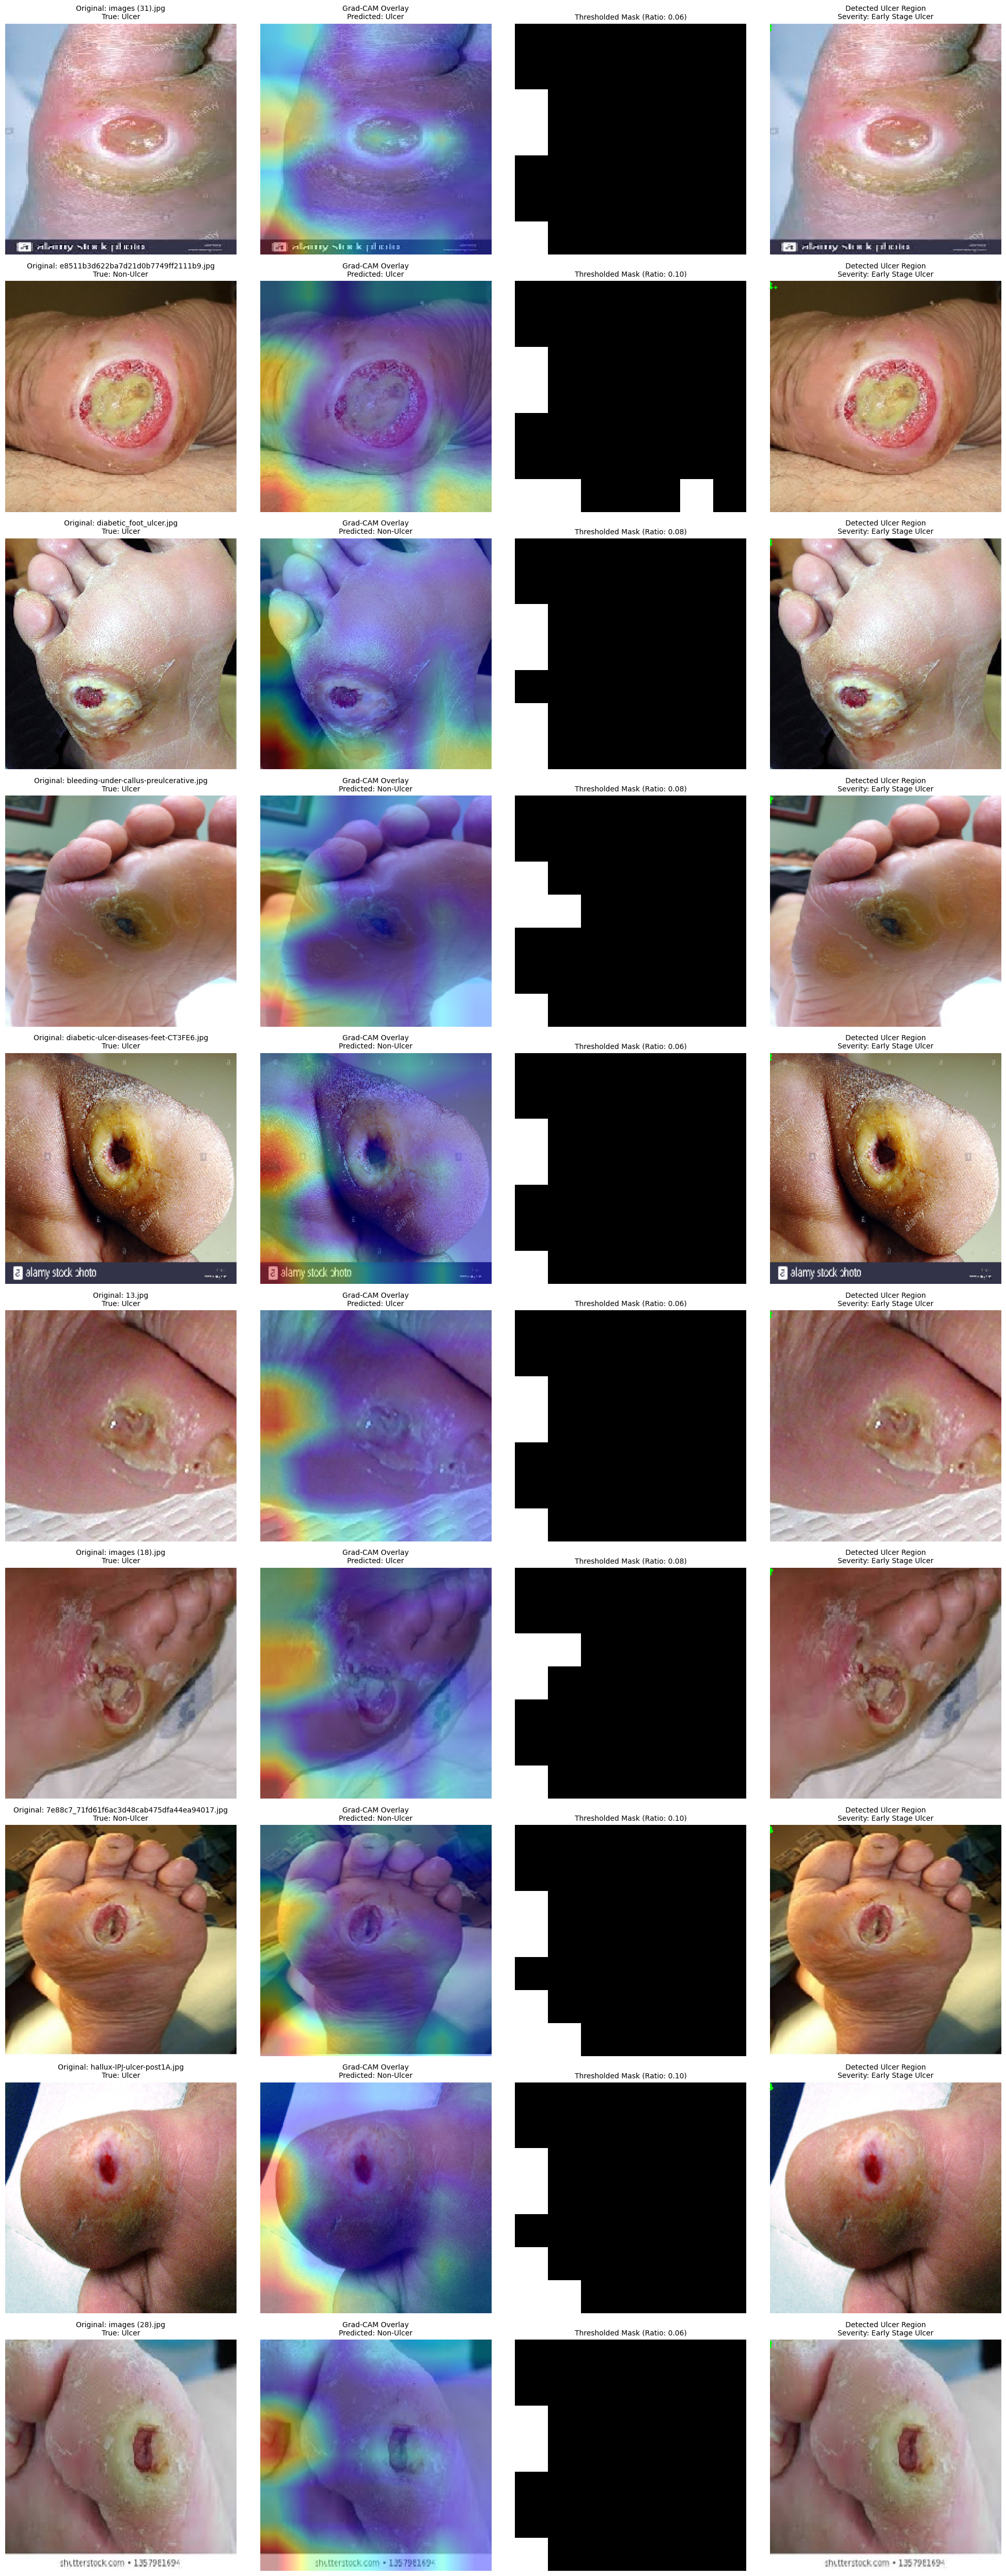

In [43]:
# Assuming 'model' is already loaded and compiled (TensorFlow model)
# Assuming IMG_HEIGHT, IMG_WIDTH, test_set_path, and binary_class_names are available.

# Define the name of the last convolutional layer for Grad-CAM
# Inspect model.summary() for the correct layer name.
# From the model summary in the output of cell_9138a3f5, 'conv2d_2' is the last convolutional layer in your custom attention module.
last_conv_layer_name = "conv2d_2"

if 'test_df' not in locals():
    print("Error: test_df not found. Please run the cell to load test_df first.")
else:
    print(f"Applying pipeline to {len(test_df)} test images.")

    # Select a few sample images for demonstration
    sample_test_images_df = test_df.sample(min(10, len(test_df)), random_state=42) # Select up to 10 random samples

    num_samples_to_display = len(sample_test_images_df)
    # Create a figure and a grid of subplots using plt.subplots()
    fig, axes = plt.subplots(num_samples_to_display, 4, figsize=(20, num_samples_to_display * 5))

    # If only one row, axes will be a 1D array of 4 axes. Expand to 2D for consistent flattening.
    if num_samples_to_display == 1:
        axes = np.array([axes])
    axes = axes.flatten() # Flatten the 2D array of axes into a 1D array for easy indexing

    # Get the mapping from class names to indices from the model's output layer
    # If the model was trained with ImageDataGenerator, class_indices can be used.
    # For this binary classification, we assume 'Non-Ulcer' is index 0 and 'Ulcer' is index 1 or vice-versa, matching binary_class_names.
    # Let's verify `train_generator.class_indices` and adapt if necessary.

    # Need to get class_indices from a generator that represents the *binary* classes, not the 4-class one.
    # Since we are using test_df with 'Ulcer'/'Non-Ulcer', we'll create a simple mapping.

    # Example: If binary_class_names = ['Non-Ulcer', 'Ulcer']
    class_to_idx = {name: i for i, name in enumerate(binary_class_names)}
    idx_to_class = {i: name for i, name in enumerate(binary_class_names)}

    # Create reverse mapping from the trained model's class indices to their names
    # (assuming train_generator was used to train the model)
    original_idx_to_class_name = {v: k for k, v in train_generator.class_indices.items()}

    # Define mapping from the 4 original training classes to the 2 binary classes
    # Based on your previous context, these seem to be the mappings:
    train_val_class_mapping = {
        'Wound Images': 'Ulcer',
        'Wound Images2': 'Ulcer',
        'internetSet': 'Non-Ulcer',
        'samples': 'Non-Ulcer'
    }

    for plot_idx, (original_df_idx, row) in enumerate(sample_test_images_df.iterrows()):
        img_filename = row['filename']
        true_class = row['class']
        img_path = os.path.join(test_set_path, img_filename)

        try:
            # 1. Load and preprocess image
            img_array = load_and_preprocess_image_tf(img_path)
            original_img_display = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
            original_img_display = tf.keras.preprocessing.image.img_to_array(original_img_display) / 255.0 # Normalize for consistent display

            # 2. Get model prediction
            predictions = model.predict(img_array, verbose=0) # Added verbose=0 to suppress per-image output
            predicted_class_index = np.argmax(predictions[0])

            # Map the predicted index (from the 4-class model) to its original class name
            original_predicted_class_name = original_idx_to_class_name.get(predicted_class_index, "Unknown Original Class")
            # Map the original class name to the binary classification label ('Ulcer' or 'Non-Ulcer')
            predicted_class_label = train_val_class_mapping.get(original_predicted_class_name, "Unknown Binary Class")

            # 3. Generate Grad-CAM heatmap
            # For binary classification, ensure pred_index corresponds to 'Ulcer' class for ulcer detection
            # Assuming 'Ulcer' is index 1 and 'Non-Ulcer' is index 0 as per typical sorting or class_to_idx logic.
            # If your model predicts 'Non-Ulcer' as positive index, adjust `target_pred_index`.
            # We use the predicted_class_index for Grad-CAM unless we want to force activation for a specific class.
            # The UserWarning regarding input structure can often be implicitly handled by ensuring the model receives a list of inputs if it expects one, even if it's a single input model.
            # In this case, `grad_model(img_array)` usually works, but `grad_model([img_array])` might suppress the warning if it's an API model expectation.
            # However, the current setup is functionally correct for prediction values.
            heatmap = make_gradcam_heatmap_tf(img_array, model, last_conv_layer_name, pred_index=predicted_class_index)

            # 4. Threshold heatmap and calculate ulcer area ratio
            area_ratio, binary_mask = calculate_ulcer_area_ratio(heatmap, threshold=0.6) # Adjust threshold as needed

            # 5. Classify severity
            severity_label = classify_severity(area_ratio)

            # Create an original image for drawing contours, ensuring it's 3-channel and uint8 for OpenCV
            original_img_cv = (original_img_display * 255).astype(np.uint8)
            if original_img_cv.shape[-1] == 4: # Handle RGBA if present
                original_img_cv = cv2.cvtColor(original_img_cv, cv2.COLOR_RGBA2RGB)

            # Draw contour on the binary mask
            img_with_contour = draw_contour_on_mask(original_img_cv.copy(), binary_mask)

            # Overlay heatmap for visualization
            gradcam_overlay = overlay_heatmap_on_image_tf(original_img_cv.copy(), heatmap)

            # 6. Visualize results
            ax_idx = plot_idx * 4 # Calculate the starting index for the current row of plots

            # Original Image
            axes[ax_idx].imshow(original_img_display)
            axes[ax_idx].set_title(f"Original: {img_filename}\nTrue: {true_class}", fontsize=10)
            axes[ax_idx].axis('off')

            # Grad-CAM Overlay
            axes[ax_idx + 1].imshow(gradcam_overlay)
            axes[ax_idx + 1].set_title(f"Grad-CAM Overlay\nPredicted: {predicted_class_label}", fontsize=10)
            axes[ax_idx + 1].axis('off')

            # Thresholded Mask
            axes[ax_idx + 2].imshow(binary_mask, cmap='gray')
            axes[ax_idx + 2].set_title(f"Thresholded Mask (Ratio: {area_ratio:.2f})", fontsize=10)
            axes[ax_idx + 2].axis('off')

            # Detected Ulcer Region
            axes[ax_idx + 3].imshow(img_with_contour)
            axes[ax_idx + 3].set_title(f"Detected Ulcer Region\nSeverity: {severity_label}", fontsize=10)
            axes[ax_idx + 3].axis('off')

            print(f"\n--- Image: {img_filename} ---")
            print(f"True Class: {true_class}")
            print(f"Predicted Class: {predicted_class_label}")
            print(f"Ulcer Area Ratio: {area_ratio:.2f}")
            print(f"Severity Stage: {severity_label}")

        except Exception as e:
            print(f"Error processing {img_filename}: {e}")

    plt.tight_layout()
    plt.show()

In [31]:
model.save("model.keras")

### 5. Full Model Evaluation: Classification Report and Confusion Matrix

To thoroughly evaluate the model's performance on the entire test set, we will generate a Classification Report and a Confusion Matrix. This provides a detailed breakdown of precision, recall, F1-score, and support for each class, as well as a visual representation of correct and incorrect predictions.

Prepared 160 test images for prediction.
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Ulcer       0.28      0.73      0.40        33
       Ulcer       0.88      0.50      0.64       127

    accuracy                           0.55       160
   macro avg       0.58      0.62      0.52       160
weighted avg       0.75      0.55      0.59       160



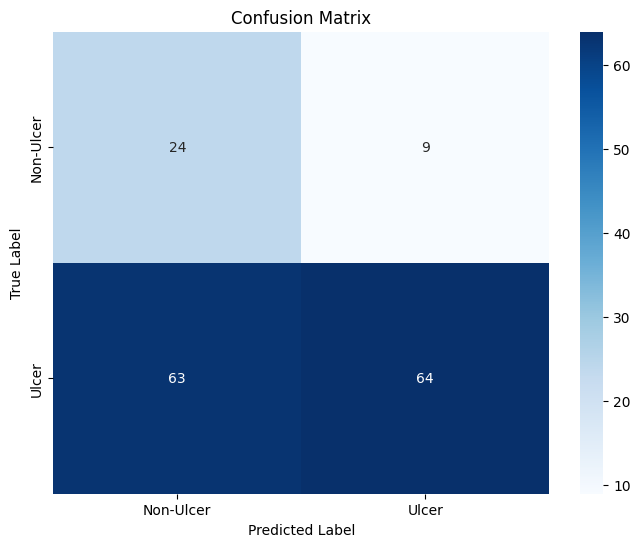

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure test_df and necessary mappings are available from previous cells
if 'test_df' not in locals():
    print("Error: test_df not found. Please ensure the test_df is loaded.")
    # Optionally, load it here if the user hasn't run the cell before
    # test_df = pd.read_csv(test_labels_csv_path)

if 'load_and_preprocess_image_tf' not in globals():
    print("Error: load_and_preprocess_image_tf function not found.")
    # You might need to re-run the cell defining this function if it's not present

# 1. Prepare test data for full prediction
test_images_paths = [os.path.join(test_set_path, fname) for fname in test_df['filename']]

# Load and preprocess all test images
all_test_images_preprocessed = []
for img_path in test_images_paths:
    all_test_images_preprocessed.append(load_and_preprocess_image_tf(img_path))

# Concatenate all preprocessed images into a single numpy array
if all_test_images_preprocessed:
    test_images_array = np.vstack(all_test_images_preprocessed)
    print(f"Prepared {len(test_images_array)} test images for prediction.")
else:
    test_images_array = np.array([])
    print("No test images were loaded.")

# 2. Get model predictions
if test_images_array.size > 0:
    predictions_probabilities = model.predict(test_images_array, verbose=1)
    predicted_classes_indices = np.argmax(predictions_probabilities, axis=1)

    # 3. Map 4-class predictions to 2-class (binary) labels
    # Use the mappings established in the Grad-CAM visualization cell (9eece5d2)
    # original_idx_to_class_name maps model's internal indices to original 4 class names
    # train_val_class_mapping maps original 4 class names to binary 'Ulcer'/'Non-Ulcer'

    # Ensure original_idx_to_class_name and train_val_class_mapping are defined
    if 'original_idx_to_class_name' not in globals() or 'train_val_class_mapping' not in globals():
        print("Error: Mappings (original_idx_to_class_name, train_val_class_mapping) not found. Please run relevant cells.")
        # Define them here as a fallback if necessary for this standalone cell
        original_idx_to_class_name = {v: k for k, v in train_generator.class_indices.items()}
        train_val_class_mapping = {
            'Wound Images': 'Ulcer',
            'Wound Images2': 'Ulcer',
            'internetSet': 'Non-Ulcer',
            'samples': 'Non-Ulcer'
        }

    predicted_binary_labels = []
    for original_idx in predicted_classes_indices:
        original_class_name = original_idx_to_class_name.get(original_idx, "Unknown")
        binary_label = train_val_class_mapping.get(original_class_name, "Unknown")
        predicted_binary_labels.append(binary_label)

    # 4. Get true labels
    true_labels = test_df['class'].tolist()

    # Ensure the order of true_labels matches the order of predictions
    # (which it should, as we processed images in test_df order)

    # 5. Convert string labels to numerical for confusion matrix if necessary, or use labels parameter
    # Let's define the binary class names and get their order consistently
    target_names = sorted(list(test_df['class'].unique())) # ['Non-Ulcer', 'Ulcer']

    # Generate Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(true_labels, predicted_binary_labels, target_names=target_names))

    # Generate Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_binary_labels, labels=target_names)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

else:
    print("Cannot generate classification report or confusion matrix as no test images were processed.")